In [ ]:
pip install Bgolearn

`HomePage` : http://bgolearn.caobin.asia/

The training data is saved in `./data/train.csv`.


It contains four features: Sn, Bi, In, and Ti, as well as two target variables: T and E. 


Determine the set of Sn, Bi, In, and Ti that maximizes the value of T and E.


Use `BgoKit`, a toolkit designed to enhance `Bgolearn`.

The optimization strategy in `BgoKit` is divided into two steps:

1. Use `Bgolearn` to predict the values of the two targets separately.
2. Plot the Pareto front in the performance space and select a point from it.

This approach is commonly referred to as single-objective Bayesian optimization combined with multi-objective selection.



In [1]:
# import training data
import pandas as pd
data = pd.read_csv('./data/data.csv')
print(data)

      Sn   Bi   In   Ti       T      E
0   92.9  3.0  2.5  0.1   64.60  20.85
1   92.7  3.0  2.5  0.3   62.59  23.69
2   92.5  3.0  2.5  0.5   72.05  22.84
3   91.9  3.0  3.5  0.1   66.60  19.79
4   91.7  3.0  3.5  0.3   70.29  21.60
5   91.5  3.0  3.5  0.5   68.33  15.95
6   91.9  4.0  2.5  0.1   77.65  16.44
7   91.7  4.0  2.5  0.3   80.49  16.64
8   91.5  4.0  2.5  0.5   81.03  15.66
9   90.9  4.0  3.5  0.1   78.59  18.44
10  90.7  4.0  3.5  0.3   84.98  15.22
11  90.5  4.0  3.5  0.5   87.58  16.29
12  90.9  5.0  2.5  0.1   87.42  15.72
13  90.7  5.0  2.5  0.3   94.48  14.92
14  90.5  5.0  2.5  0.5   95.07  15.05
15  89.9  5.0  3.5  0.1   92.51  13.24
16  89.7  5.0  3.5  0.3   89.85  11.91
17  89.5  5.0  3.5  0.5   90.41  11.39
18  86.8  5.5  5.5  0.7  106.65  11.80
19  86.9  5.5  5.4  0.7  110.56  13.69
20  86.9  5.5  5.5  0.6  113.44  12.64
21  92.5  2.5  3.4  0.1   65.51  21.25
22  92.6  2.5  3.3  0.1   62.67  26.36
23  92.4  2.5  3.4  0.2   65.40  23.78
24  92.4  1.5  4.5  0.1  

In [2]:
# generate virtual data, viz, define the searching space

import numpy as np

Bi = np.arange(1.5, 5.6, 0.1)
In = np.arange(1.5, 5.6, 0.1)
Ti = np.arange(0.1, 0.8, 0.1)

X1,X2,X3 = np.meshgrid(Bi,In,Ti)
Visual_samples = np.vstack([X1.ravel(), X2.ravel(),X3.ravel()]).T
Visual_samples = pd.DataFrame(Visual_samples)
Visual_samples.columns=['Bi','In','Ti']

Sn = 100 - 1.5 - Visual_samples['Bi'] - Visual_samples['In'] - Visual_samples['Ti']
Visual_samples.insert(0, 'Sn', Sn)
Visual_samples.to_csv('./data/Visual_samples.csv',index=0)
print(Visual_samples)

         Sn   Bi   In   Ti
0      95.4  1.5  1.5  0.1
1      95.3  1.5  1.5  0.2
2      95.2  1.5  1.5  0.3
3      95.1  1.5  1.5  0.4
4      95.0  1.5  1.5  0.5
...     ...  ...  ...  ...
11762  87.2  5.5  5.5  0.3
11763  87.1  5.5  5.5  0.4
11764  87.0  5.5  5.5  0.5
11765  86.9  5.5  5.5  0.6
11766  86.8  5.5  5.5  0.7

[11767 rows x 4 columns]


In [6]:
pip install BgoKit 

Note: you may need to restart the kernel to use updated packages.


 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2024-09-18 11:18:00  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [95.3  1.5  1.5  0.2]
The predictions of Bgolearn are : 
 y =  62.169546305748696
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [87.7  5.5  4.9  0.4]
The predictions of Bg

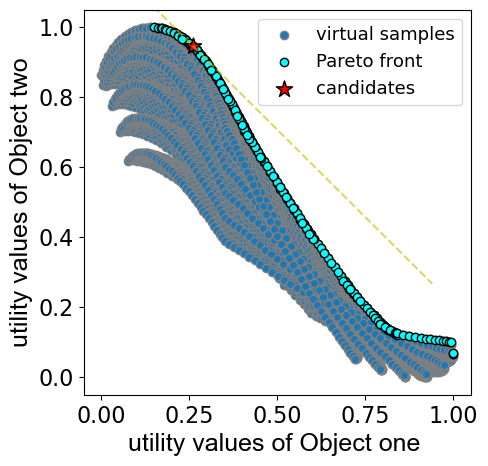

The optimal condidate recommended by BgoKit is : [[93.3  3.3  1.5  0.4]]


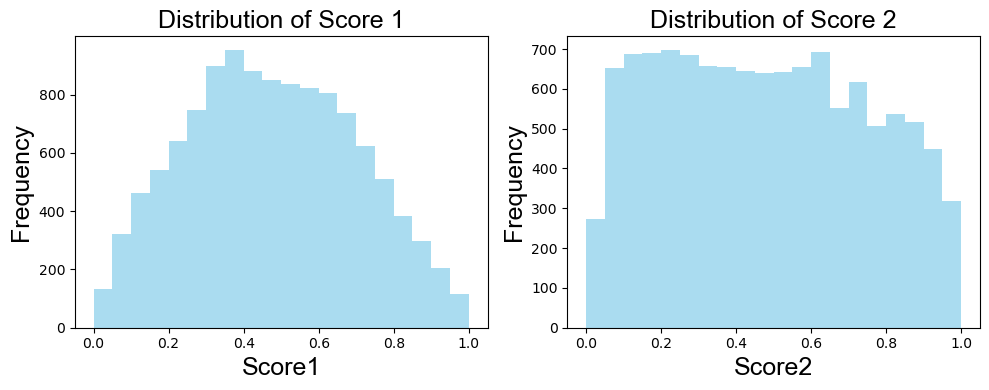

In [11]:
from BgoKit import ToolKit
import Bgolearn.BGOsampling as BGOS
Bgolearn = BGOS.Bgolearn() 


Mymodel_1 = Bgolearn.fit(data_matrix = data.iloc[:,:-2], Measured_response = data.iloc[:,-2], virtual_samples = Visual_samples)
score_1, _= Mymodel_1.UCB()  

Mymodel_2 = Bgolearn.fit(data_matrix = data.iloc[:,:-2], Measured_response = data.iloc[:,-1], virtual_samples = Visual_samples)
score_2, _= Mymodel_2.UCB()

Model = ToolKit.MultiOpt(Visual_samples,[score_1,score_2])
Model.BiSearch()
Model.plot_distribution()



Sometimes it works well, while other times it does not. The reason is straightforward: multi-objective Bayesian optimization is not always essential.

We can apply `MultiBgolearn` for multi-objective Bayesian optimization. `MultiBgolearn` incorporates multi-objective machine learning modeling and multi-objective optimization, considering the trade-offs between each target simultaneously.



In [2]:
pip install MultiBgolearn

Note: you may need to restart the kernel to use updated packages.


 __  __         _  _    _          ___   _        _      
|  \/  | _   _ | || |_ (_)        / _ \ | |__    (_) ___ 
| |\/| || | | || || __|| | _____ | | | || '_ \   | |/ __|
| |  | || |_| || || |_ | ||_____|| |_| || |_) |  | |\__ \
|_|  |_| \__,_||_| \__||_|        \___/ |_.__/  _/ ||___/
                                               |__/      

MultiBgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/MultiBgolearn
Doc : https://bgolearn.netlify.app/
Executed on : 2024-09-18 13:54:03  | Have a great day.
LOOCV is used to evaluate models, and the best one will be recommended after evaluation.

Evaluating RandomForest...
R2 score for RandomForest: 0.8166

Evaluating GradientBoosting...
R2 score for GradientBoosting: 0.7960

Evaluating LinearRegression...
R2 score for LinearRegression: 0.7142

Evaluating Lasso...
R2 score for Lasso: -0.0784

Evaluating Ridge...
R2 score for Ridge: 0.7143

Evaluating SVR...
R2 score for SVR: 0.7871

Evaluating GaussianProcess...
R2 score for Gau

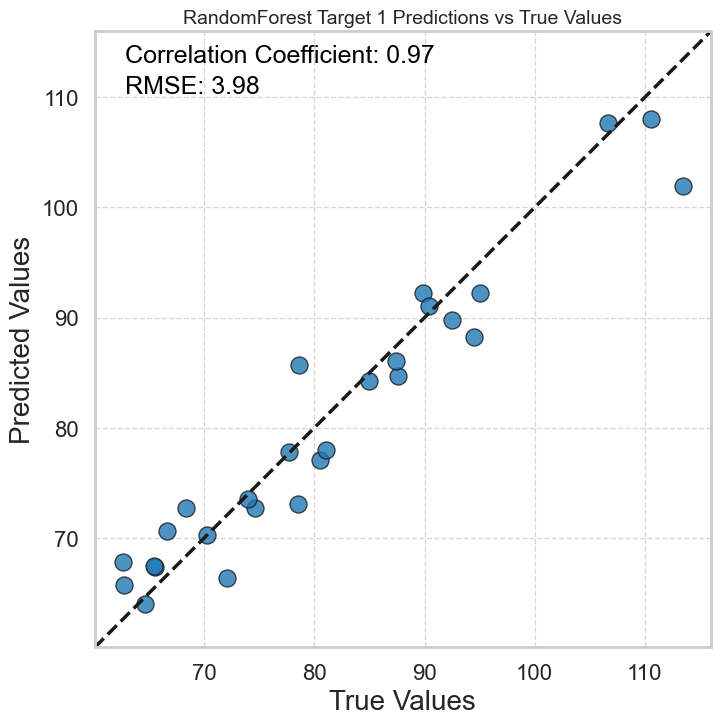

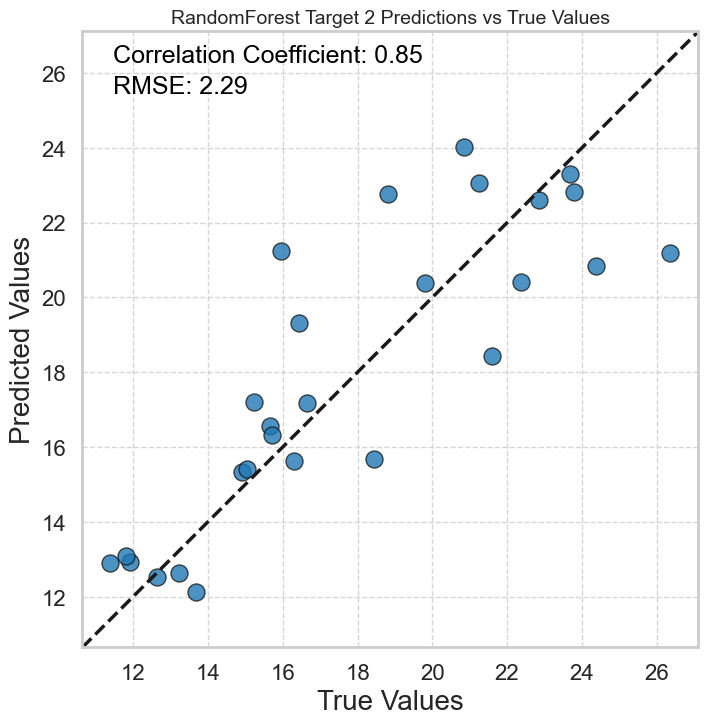

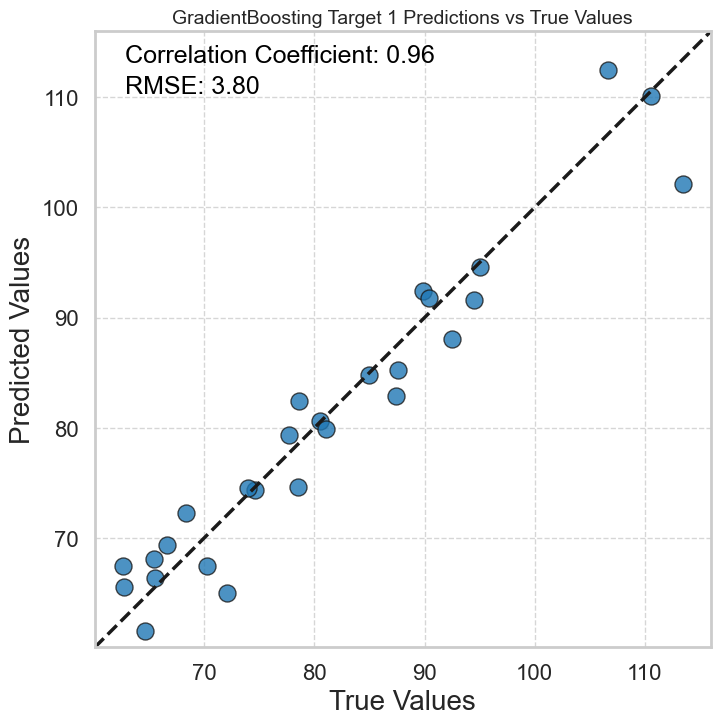

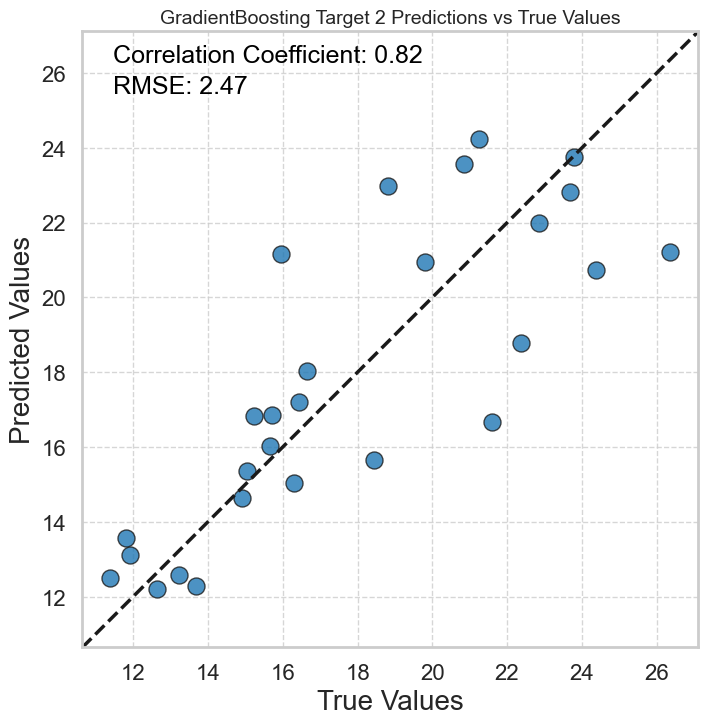

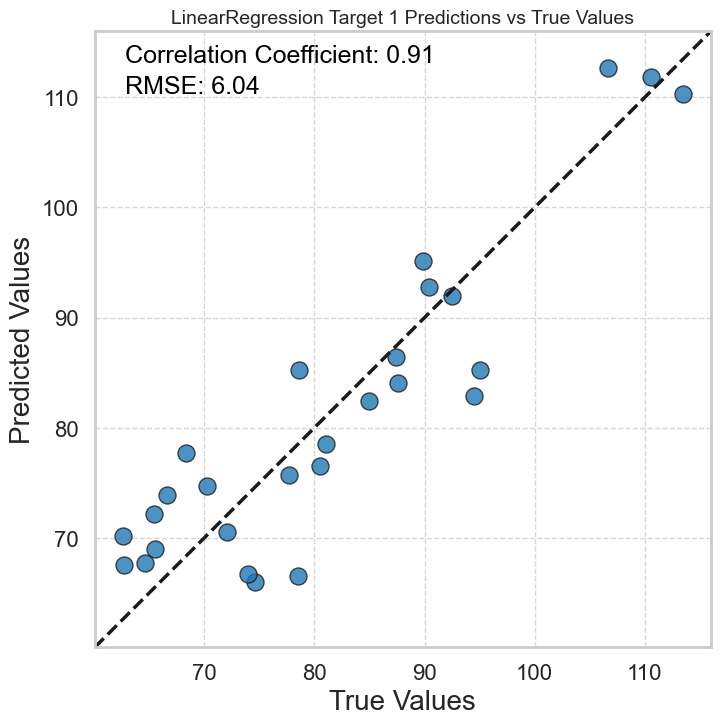

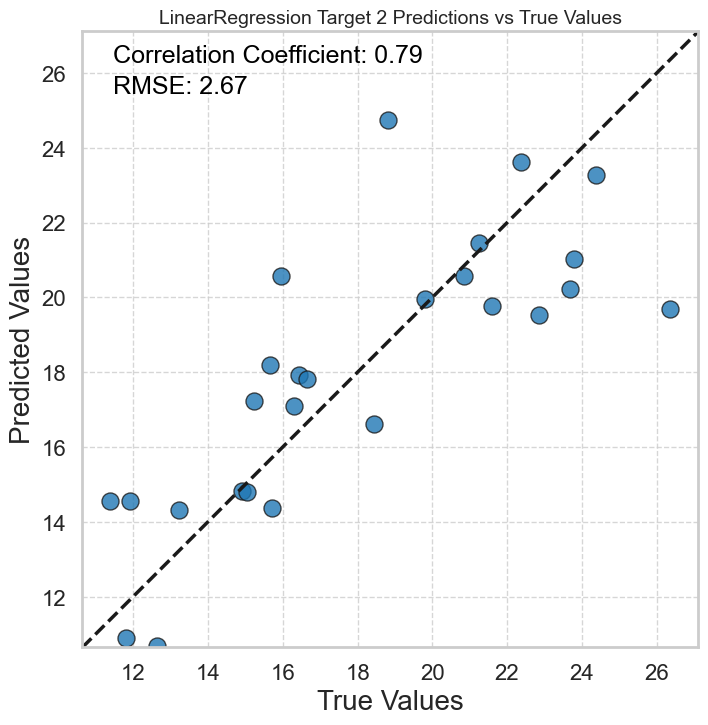

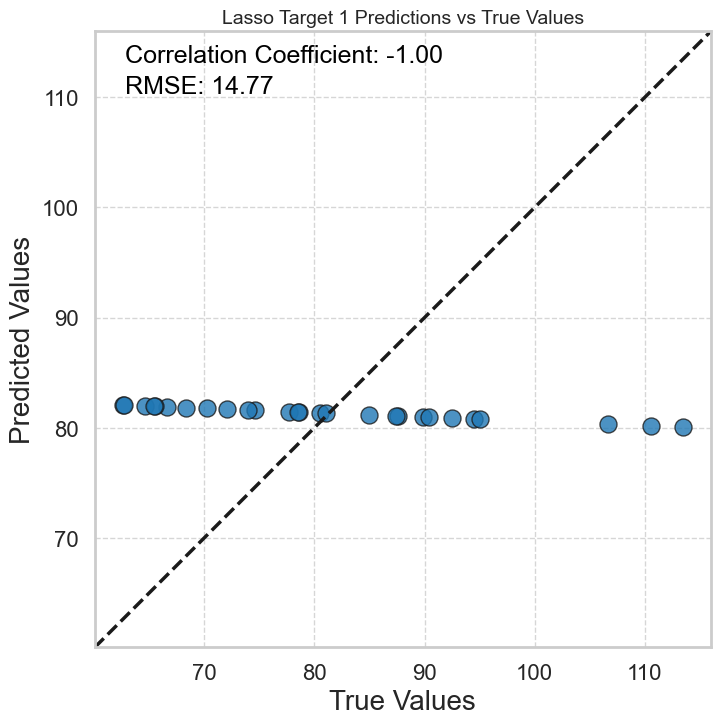

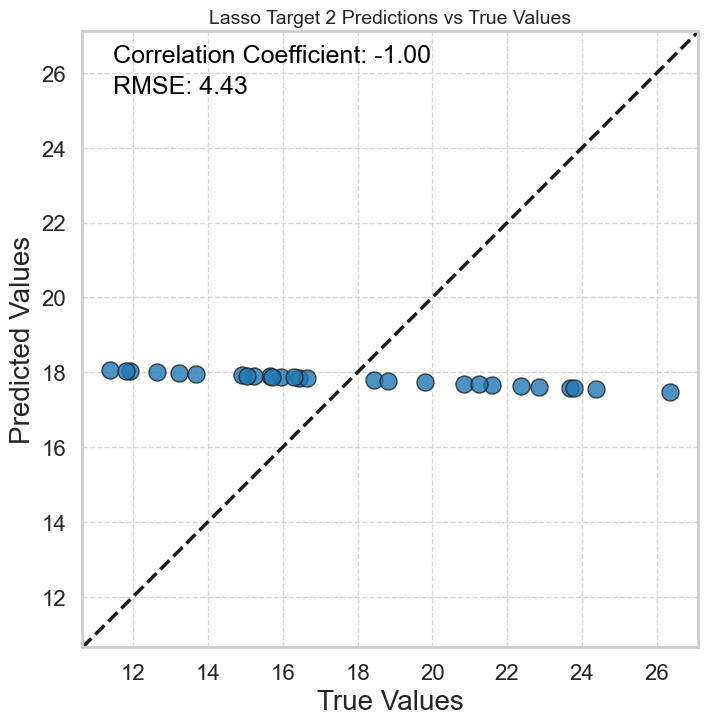

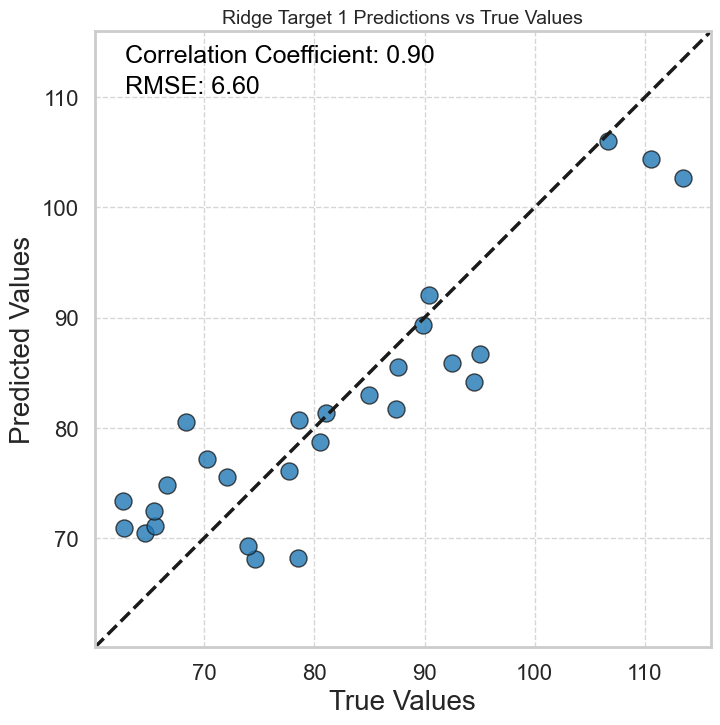

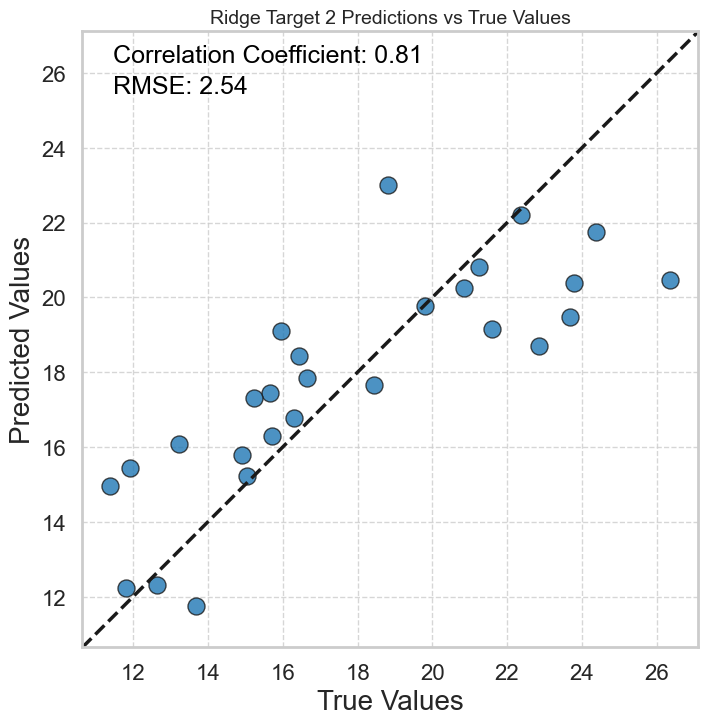

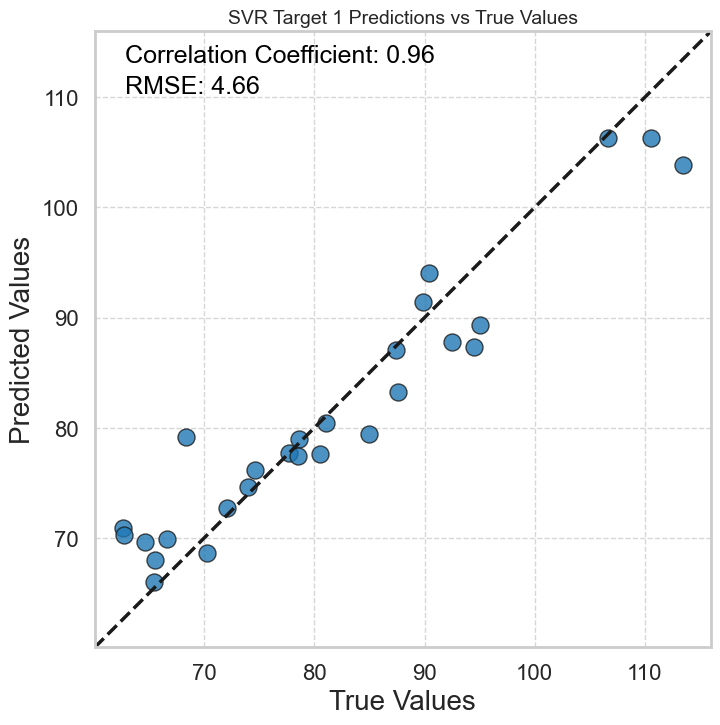

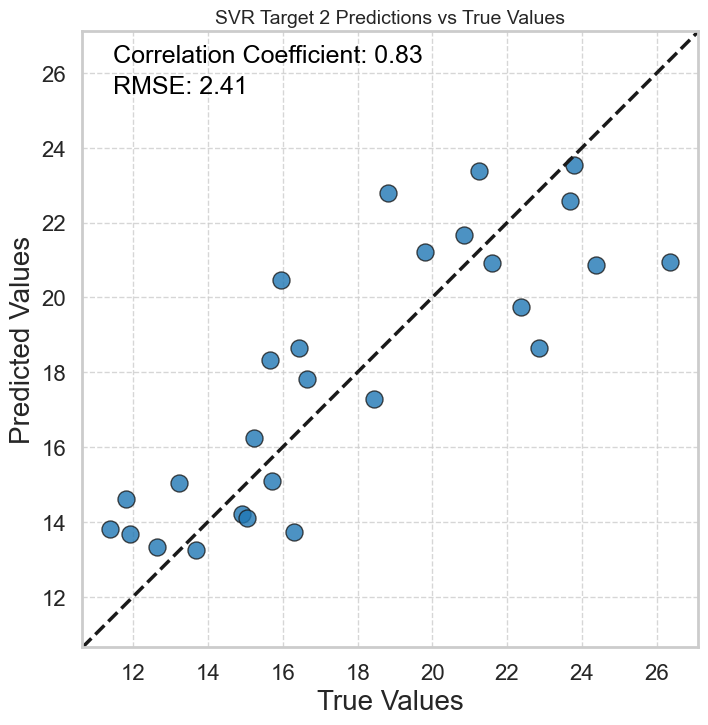

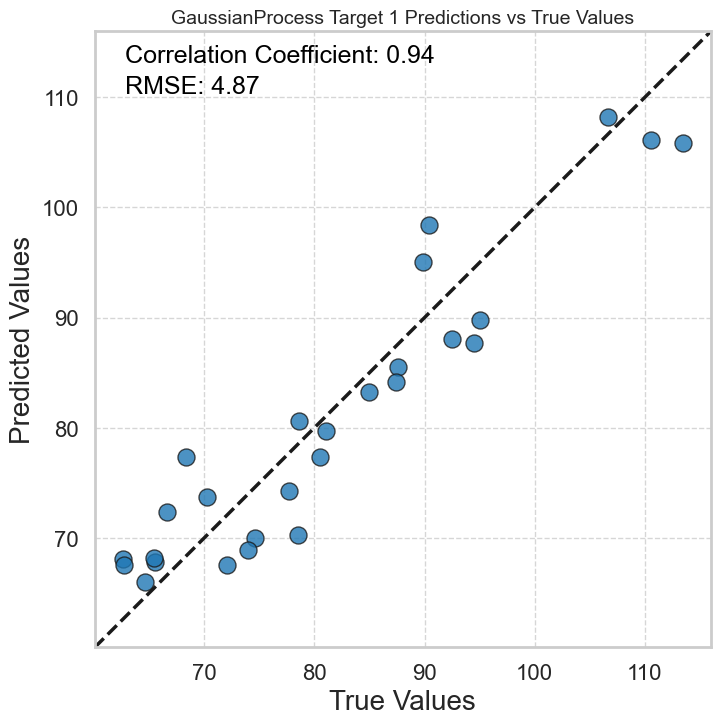

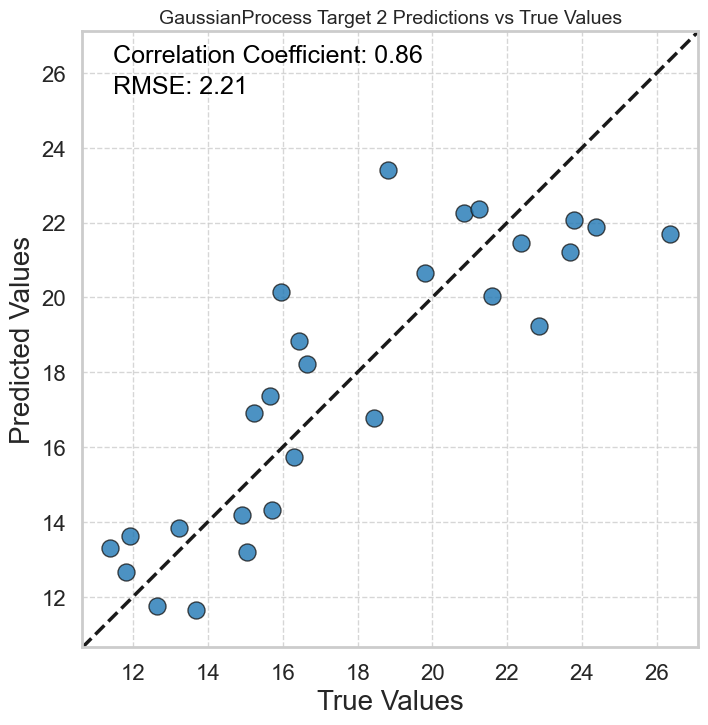

In [1]:
from MultiBgolearn import bgo

# Define your dataset and virtual space paths
dataset_path = './data/data.csv'
VS_path = './data/Visual_samples.csv'

# Set the number of objectives (e.g., 3 for three-objective optimization)
object_num = 2

# Apply Multi-Objective Bayesian Global Optimization
VS_recommended, improvements, index = bgo.fit(
    dataset_path, 
    VS_path, 
    object_num, 
    max_search=True, 
    method='EHVI', 
    #assign_model='GaussianProcess', 
    bootstrap=5
)

In [1]:
from MultiBgolearn import bgo

# Define your dataset and virtual space paths
dataset_path = './data/data.csv'
VS_path = './data/Visual_samples.csv'

# Set the number of objectives (e.g., 3 for three-objective optimization)
object_num = 2

# Apply Multi-Objective Bayesian Global Optimization
VS_recommended, improvements, index = bgo.fit(
    dataset_path, 
    VS_path, 
    object_num, 
    max_search=True, 
    method='PI', 
    assign_model='SVR', 
    bootstrap=5
)

 __  __         _  _    _          ___   _        _      
|  \/  | _   _ | || |_ (_)        / _ \ | |__    (_) ___ 
| |\/| || | | || || __|| | _____ | | | || '_ \   | |/ __|
| |  | || |_| || || |_ | ||_____|| |_| || |_) |  | |\__ \
|_|  |_| \__,_||_| \__||_|        \___/ |_.__/  _/ ||___/
                                               |__/      

MultiBgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/MultiBgolearn
Doc : https://bgolearn.netlify.app/
Executed on : 2024-12-13 15:22:33  | Have a great day.
The next recommended data by method 'PI' is: [94.8  1.5  1.5  0.7]
